In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
%matplotlib inline
from ipywidgets import interact, fixed
import ipywidgets as widgets
from numba import njit, prange
import pickle
from typing import List, Tuple, Callable, Any

from utils import MovingFunctionCalculator
from utils import Analytical
from utils import Plotter

In [6]:
@njit
def calc_propensities(grid:np.ndarray[Any, np.dtype[np.float64]], kon, koff, kstep):
    n_on = len(grid)
    n_off = np.sum(grid)
    n_step = np.sum(grid)

    aon = n_on*kon
    aoff = n_off*koff
    astep = n_step*kstep

    return np.array([aon, aoff, astep])

In [7]:
@njit
def bind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    side = np.random.randint(len(grid))
    grid[side] += 1

@njit
def unbind_kinesin(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)

    grid[side] -= 1

@njit
def move_kinesin_w_fall(grid: np.ndarray[Any, np.dtype[np.float64]]) -> None:
    S = np.cumsum(grid)
    r = np.random.randint(low = 1, high = int(S[-1])+1)
    side = np.argmax(S>=r)
    
    grid[side] -= 1
    if side != len(grid)-1:
        grid[side+1] += 1

In [8]:
@njit
def step(grid, kon, koff, kstep)->Tuple[float, int]:
    r1 = np.random.uniform()
    r2 = np.random.uniform()

    A = calc_propensities(grid, kon, koff, kstep)
    R_tot = np.sum(A)
    
    A_normalised = np.cumsum(A)/R_tot

    dt = (1/R_tot) * np.log(1/r1)
    idx = np.argwhere(A_normalised>r2)[0][0]


    return dt, int(idx)

In [9]:
@njit
def simulation(L, T, kon, koff, kstep):
    time = 0.0
    block = 0
    period = 0.1
    next_write_time = period
    blocks = int(T/period)

    grid:np.ndarray[Any, np.dtype[np.float64]] = np.zeros(L)

    DATA = np.zeros((blocks, L))
    TIMES= np.zeros(blocks)

    while time<T:
        dt, idx = step(grid, kon, koff, kstep)
        time+= dt      
        if idx==0:
            bind_kinesin(grid)
        elif idx==1:
            unbind_kinesin(grid)
        else:
            move_kinesin_w_fall(grid)
            
        if next_write_time<time:
            DATA[block,:] = grid
            TIMES[block] = time
            block+=1
            next_write_time+=period

    return DATA[:block], TIMES[:block]

In [16]:
@njit(parallel=True)
def multiple_SIMS_last(num, L, T, kon, koff, kstep):

    LAST_FRAMES = np.zeros((num, L))
    for i in prange(num):
        DATA, TIMES = simulation(L, T, kon, koff, kstep)
        LAST_FRAMES[i,:]=DATA[-1,:]
    return LAST_FRAMES

In [11]:
def theoretical_num_kinesins(L, kon, koff, kstep):
    n = np.arange(0,L)
    if kstep==0:
        return L*kon/koff
    else:
        return np.sum((kon/koff) * (1- np.exp(-koff*n/kstep)))

In [17]:
L = 300
T = 100
koff = 1
kon = 1
kstep = 100

options={'L':L, 'T':T, 'koff':koff, 'kon':kon, 'kstep':kstep}

In [30]:
res = multiple_SIMS_last(1000, L, T, kon, koff, kstep)

In [31]:
res.shape

(1000, 300)

In [32]:
mean = np.mean(res, axis=0)
var = np.var(res, axis=0)

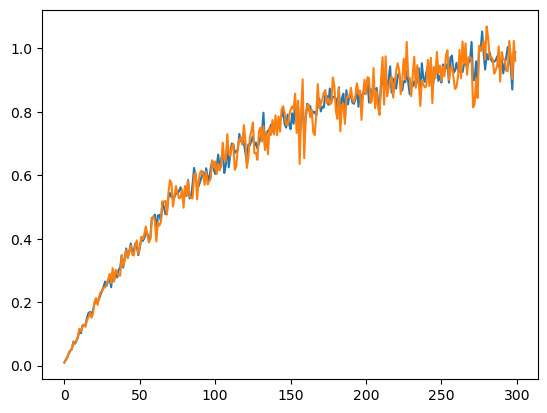

In [33]:
plt.plot(mean)
plt.plot(var)

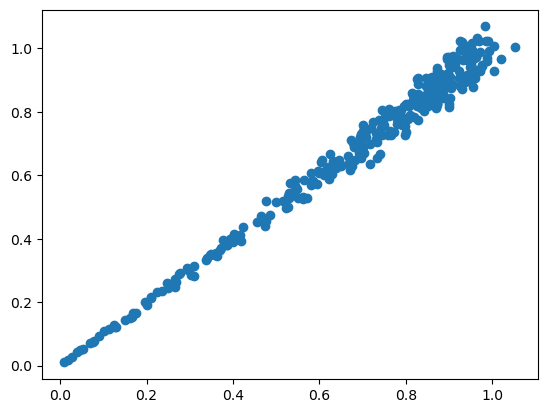

In [36]:
plt.scatter(mean, var)

In [14]:
# @njit
# def mean_var(L, T, kon, koff, kstep):
#     data, times = simulation(L, T, kon, koff, kstep)
#     return np.sum(data[-1, :])

@njit
def mean_var(L, T, kon, koff, kstep):
    data, times =simulation(L, T, kon, koff, kstep)
    return data[-1, :]

In [ ]:
@njit(parallel=True)
def calc_ratio_kon(L, T, kon_list:np.ndarray, kstep): # Assemble average only
    res = np.zeros(len(kon_list))
    for i in prange(len(kon_list)):
        A = mean_var(L, T, kon_list[i], 1, kstep)
        res[i] = A        
    return res

In [128]:
# @njit(parallel=True)
# def calc_ratio_kon(L, T, kon_list:np.ndarray, kstep): # Assemble average only
#     res = np.zeros(len(kon_list))
#     for i in prange(len(kon_list)):
#         A = mean_var(L, T, kon_list[i], 1, kstep)
#         res[i] = A        
#     return res

In [4]:
kon_list = np.logspace(-4,2, 60)

In [8]:
means_th = np.array(
    [theoretical_num_kinesins(300, kon, 1, 0) for kon in kon_list]
)

# kstep = 0 
## Only assemble average


In [131]:
# Uncomment to run

# SAMPLES = 250         
# RES = np.zeros((SAMPLES, len(kon_list)))
# for sample in range(SAMPLES):
#     A = calc_ratio_kon(300,20,kon_list, 0)
#     RES[sample, :] = A[:]

In [132]:
# with open('./mean_var_zero_kstep', 'wb') as f:
#     pickle.dump(RES, f)

In [9]:
with open('./mean_var_zero_kstep', 'rb') as f:
    RES=pickle.load(f)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


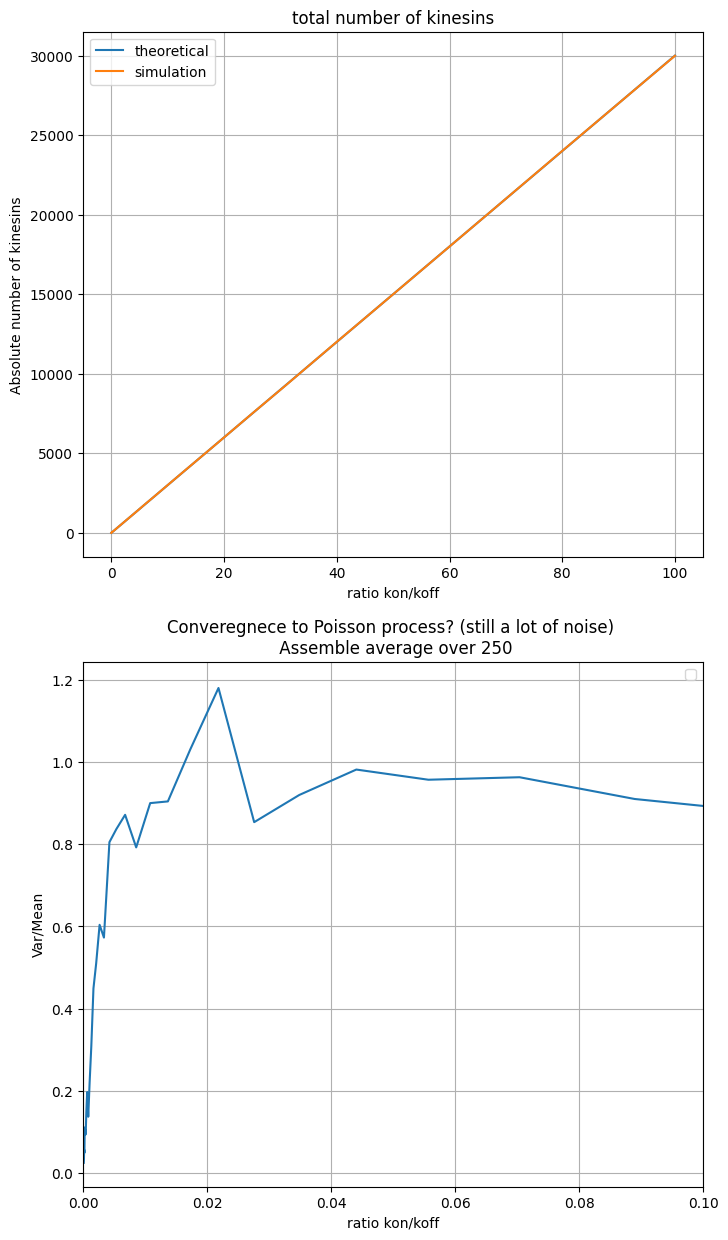

In [17]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,15))
ax1.plot(kon_list, means_th, label ="theoretical")
ax1.plot(kon_list, np.mean(RES[:,:], axis=0), label = "simulation")
ax1.set(
    title = "total number of kinesins",
    xlabel = "ratio kon/koff",
    ylabel = "Absolute number of kinesins"
)
ax1.grid()
ax1.legend()

ax2.plot(kon_list,np.var(RES[:,:], axis=0)/np.mean(RES[:,:], axis=0) )
ax2.set(
    title = "Converegnece to Poisson process? (still a lot of noise) \n Assemble average over 250",
    xlabel = "ratio kon/koff",
    ylabel = "Var/Mean",
    xlim=[0,0.1]
)
ax2.grid()
ax2.legend()

# kstep=10
## Again only assemble average

In [147]:
means_th = np.array(
    [theoretical_num_kinesins(300, kon, 1, 10) for kon in kon_list]
)

In [ ]:
@njit(parallel=True)
def assemble(SAMPLES):
    RES = np.zeros((SAMPLES, len(kon_list)))
    for sample in prange(SAMPLES):
        A = calc_ratio_kon(300,20,kon_list, 2)
        RES[sample, :] = A[:]
    return RES


In [ ]:
# total = assemble(250)

In [148]:
# with open('./mean_var_high_kstep', 'wb') as f:
#     pickle.dump(total, f)

In [11]:
with open('./mean_var_high_kstep', 'rb') as f:
    total = pickle.load(f)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


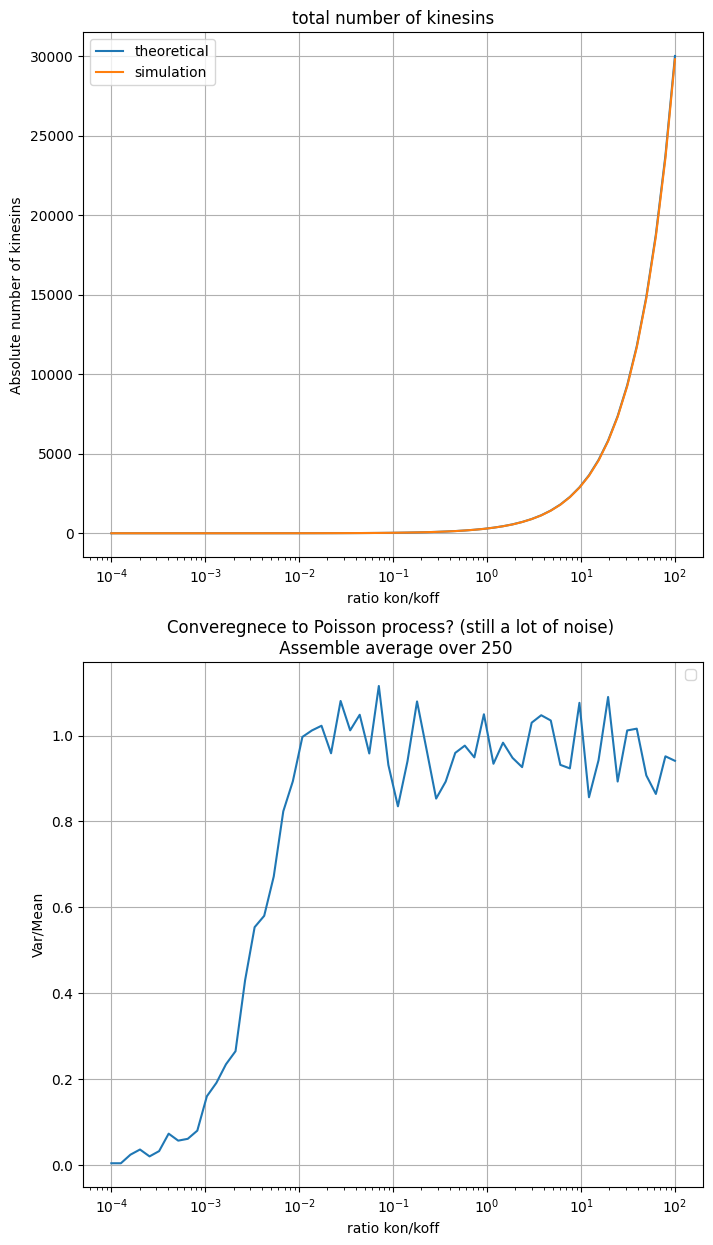

In [12]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,15))
ax1.semilogx(kon_list, means_th, label ="theoretical")
ax1.semilogx(kon_list, np.mean(total[:,:], axis=0), label = "simulation")
ax1.set(
    title = "total number of kinesins",
    xlabel = "ratio kon/koff",
    ylabel = "Absolute number of kinesins"
)
ax1.grid()
ax1.legend()

ax2.semilogx(kon_list,np.var(total[:,:], axis=0)/np.mean(total[:,:], axis=0) )
ax2.set(
    title = "Converegnece to Poisson process? (still a lot of noise) \n Assemble average over 250",
    xlabel = "ratio kon/koff",
    ylabel = "Var/Mean"
)
ax2.grid()
ax2.legend()

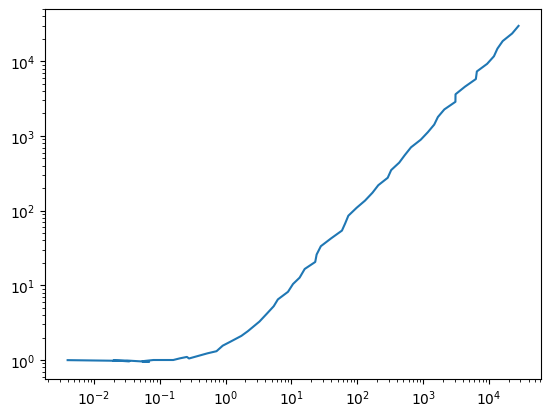

In [19]:
plt.loglog(np.var(total[:,:], axis=0), np.mean(total[:,:], axis=0))

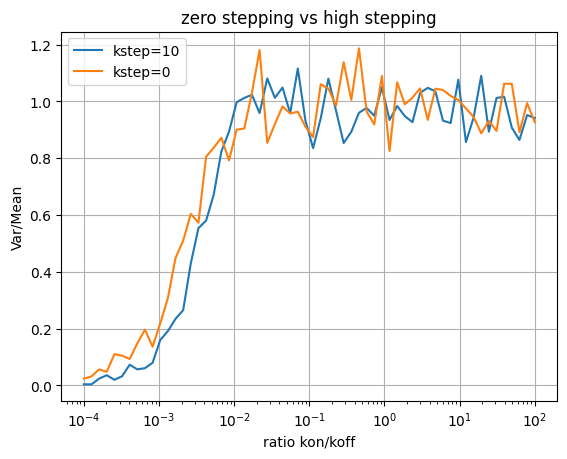

In [13]:
fig, ax = plt.subplots(1,1)

ax.semilogx(kon_list,np.var(total[:,:], axis=0)/np.mean(total[:,:], axis=0) , label = "kstep=10")
ax.semilogx(kon_list,np.var(RES[:,:], axis=0)/np.mean(RES[:,:], axis=0) ,label = "kstep=0")

ax.set(
    title="zero stepping vs high stepping",
    xlabel = "ratio kon/koff",
    ylabel = "Var/Mean"
)
ax.grid()
ax.legend()